Esercizio Sul database titanic, effettuiamo le seguenti analisi: • Riusciamo a calcolare quanti ponti c'erano sulla nave (prima lettera dei dati nella colonna Cabin)? • Visualizzare un grafico con il numero di passeggeri di ogni classe di imbarco (colonna PClass) • Fare la stessa cosa per la colonna Survived • Qual era la distribuzione delle tariffe (Fare)? • Riusciamo a vedere la distribuzione delle età dei passeggeri rispetto alla classe di imbarco con un boxplot? • Visualizziamo un boxplot rispetto alle colonne Fare e Survived; che cose ne deduciamo?

In [1]:
# 1. Importazione librerie

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
#2. Importazione del database Titanic

# Se il file titanic.csv è nella stessa cartella del notebook:
df = pd.read_csv("titanic.csv")

# Visualizziamo le prime righe
df.head()

,PassengerId,PClass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,EmbarkDate
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0,10-4-1912
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,1,11-4-1912
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.93,NaN,S,1,10-4-1912
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,1,10-4-1912
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,0,10-4-1912


In [4]:
# 3. Pulizia iniziale e overview del dataset

df.info()
df.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   PClass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1309 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1309 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
 11  Survived     1309 non-null   int64  
 12  EmbarkDate   1307 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 133.1+ KB


,PassengerId,PClass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,EmbarkDate
count,1309.000000,1309.000000,1309,1309,1309.000000,1309.000000,1309.000000,1309,1309.000000,295,1307,1309.000000,1307
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,NaN,2
top,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,NaN,10-4-1912
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,NaN,914
mean,655.000000,2.294882,NaN,NaN,23.877517,0.498854,0.385027,NaN,33.270825,NaN,NaN,0.372804,NaN
std,378.020061,0.837836,NaN,NaN,17.590845,1.041658,0.865560,NaN,51.747086,NaN,NaN,0.483735,NaN
min,1.000000,1.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,0.000000,NaN
25%,328.000000,2.000000,NaN,NaN,7.000000,0.000000,0.000000,NaN,7.900000,NaN,NaN,0.000000,NaN
50%,655.000000,3.000000,NaN,NaN,24.000000,0.000000,0.000000,NaN,14.450000,NaN,NaN,0.000000,NaN
75%,982.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.280000,NaN,NaN,1.000000,NaN


In [5]:
#Analisi 1 — Calcolare i ponti (prima lettera della colonna Cabin)

df["Deck"] = df["Cabin"].astype(str).str[0]
df["Deck"].value_counts()

Deck
n    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

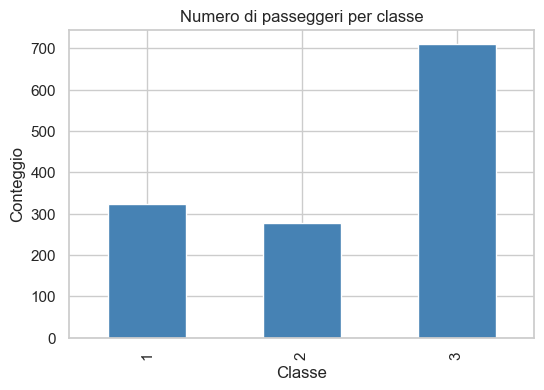

In [6]:
#Analisi 2 — Grafico: numero di passeggeri per classe (PClass)

plt.figure(figsize=(6,4))
df["PClass"].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Numero di passeggeri per classe")
plt.xlabel("Classe")
plt.ylabel("Conteggio")
plt.show()

Esercizio Scarichiamo il dataset stockdata.csv dalla piattaforma o da https://github.com/plotly/datasets/blob/master/stockdata.csv e: • Visualizziamo l'andamento delle azioni della Apple ("AAPL") • Visualizziamo l'andamento di tutte le azioni del dataset • Visualizziamo l'andamento di Microsoft ("MSFT") e IBM ("IBM") negli anni 2012 e 2013 • Con un istogramma, troviamo il range di valori che le azioni di Microsoft hanno assunto più spesso

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carichiamo il dataset direttamente da GitHub
url = "https://raw.githubusercontent.com/plotly/datasets/master/stockdata.csv"
df = pd.read_csv(url)

# Visualizziamo le prime righe per capire la struttura
df.head()


,MSFT,IBM,SBUX,AAPL,GSPC,Date
0,23.950705,80.517962,16.149666,11.086612,1416.599976,2007-01-03
1,23.910599,81.378851,16.167992,11.332687,1418.339966,2007-01-04
2,23.774242,80.642129,16.099269,11.251984,1409.709961,2007-01-05
3,24.006852,81.867244,16.039710,11.307550,1412.839966,2007-01-08
4,24.030914,82.835742,15.970989,12.246870,1412.109985,2007-01-09


In [5]:
df.columns



Index(['MSFT', 'IBM', 'SBUX', 'AAPL', 'GSPC', 'Date'], dtype='object')

In [6]:
df['Date'] = pd.to_datetime(df['Date'])


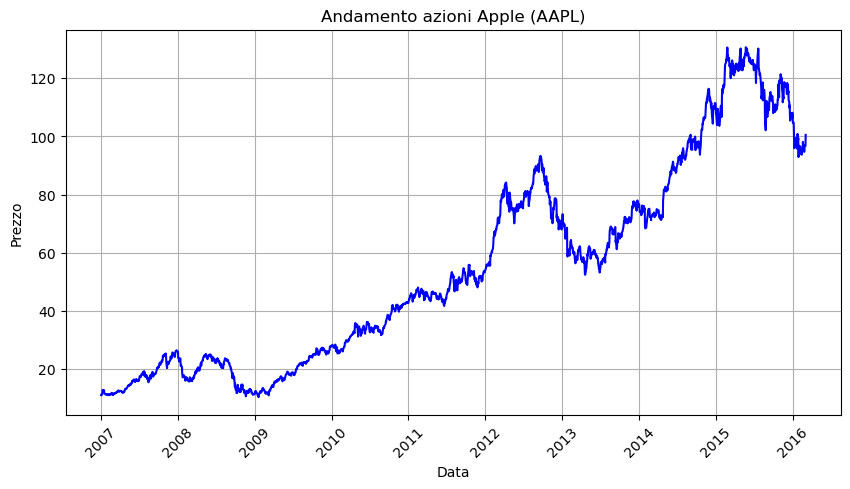

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['AAPL'], color='blue')

plt.title("Andamento azioni Apple (AAPL)")
plt.xlabel("Data")
plt.ylabel("Prezzo")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


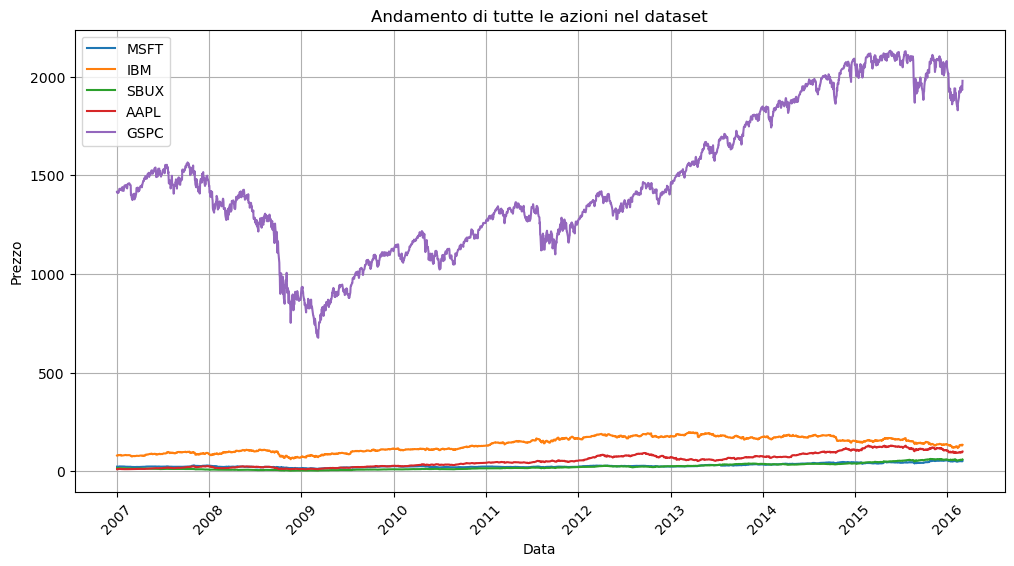

In [8]:
plt.figure(figsize=(12,6))

for col in df.columns:
    if col != 'Date':  # escludiamo la colonna Date
        plt.plot(df['Date'], df[col], label=col)

plt.title("Andamento di tutte le azioni nel dataset")
plt.xlabel("Data")
plt.ylabel("Prezzo")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


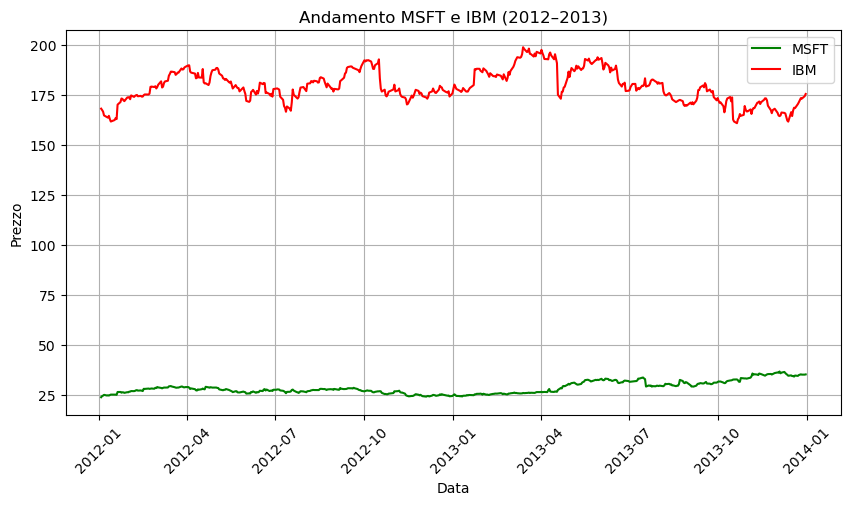

In [9]:
df_12_13 = df[(df['Date'].dt.year >= 2012) & (df['Date'].dt.year <= 2013)]

plt.figure(figsize=(10,5))
plt.plot(df_12_13['Date'], df_12_13['MSFT'], label='MSFT', color='green')
plt.plot(df_12_13['Date'], df_12_13['IBM'], label='IBM', color='red')

plt.title("Andamento MSFT e IBM (2012–2013)")
plt.xlabel("Data")
plt.ylabel("Prezzo")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


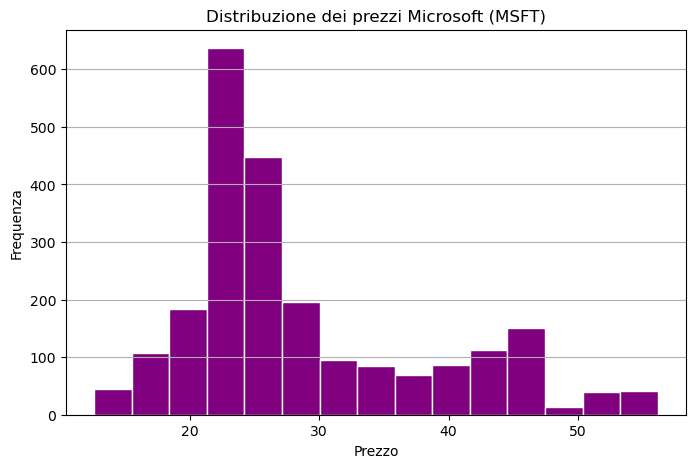

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['MSFT'], bins=15, color='purple', edgecolor='white')

plt.title("Distribuzione dei prezzi Microsoft (MSFT)")
plt.xlabel("Prezzo")
plt.ylabel("Frequenza")
plt.grid(axis='y')
plt.show()


Esercizio Scarichiamo il dataset metal_bands_2017.csv dalla piattaforma e: • Con Seaborn visualizziamo l'istogramma del numero dei fan delle varie band; cosa si vede? Cose ne deduciamo? • Delle band che suonano sia Progressive che Thrash, realizziamo un barplot che mostri quanti fan ci sono in totale rispetto al paese di origine (nota: in questo caso specifico, per accedere alla colonna "style" dovremo usare .loc[:, "style"] e non .style perché quest'ultimo è un metodo) • Visualizziamo un istogramma delle date di formazione delle band (potremo dover convertire in qualche modo questo dato); si nota qualche trend?

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carichiamo il dataset
df = pd.read_csv("metal_bands_2017.csv", encoding="latin1")

df.head()


,Unnamed: 0,band_name,fans,formed,origin,split,style
0,0,Iron Maiden,4195,1975,United Kingdom,-,"New wave of british heavy,Heavy"
1,1,Opeth,4147,1990,Sweden,1990,"Extreme progressive,Progressive rock,Progressive"
2,2,Metallica,3712,1981,USA,-,"Heavy,Bay area thrash"
3,3,Megadeth,3105,1983,USA,1983,"Thrash,Heavy,Hard rock"
4,4,Amon Amarth,3054,1988,Sweden,-,Melodic death


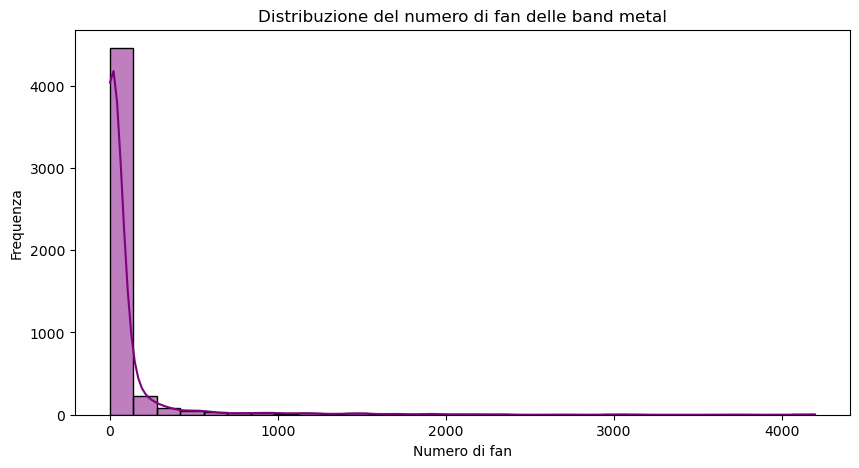

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['fans'], bins=30, kde=True, color='purple')

plt.title("Distribuzione del numero di fan delle band metal")
plt.xlabel("Numero di fan")
plt.ylabel("Frequenza")
plt.show()


2. Istogramma del numero di fan delle band
Cosa si vede?
La distribuzione è fortemente sbilanciata a destra (right‑skewed).Pochissime band hanno tantissimi fan (Iron Maiden, Opeth, Metallica…)La maggior parte delle band ha un numero di fan molto più basso.
Cosa deduciamo?
Il metal ha una struttura “a piramide”: poche band enormi, molte band piccole.È una distribuzione tipica dei fenomeni culturali (effetto superstar).

In [14]:
# Filtriamo le band che contengono entrambi gli stili Progressive e Trash
mask = df['style'].str.contains("Progressive", case=False) & \
       df['style'].str.contains("Thrash", case=False)

df_prog_thr = df[mask]

df_prog_thr


,Unnamed: 0,band_name,fans,formed,origin,split,style
6,6,Death,2690,1983,USA,2001,"Progressive death,Death,Progressive thrash"
56,56,Death,2690,1983,USA,2001,"Progressive death,Death,Progressive thrash"
103,103,Nevermore,1051,1991,USA,1991,"Heavy,Progressive,Thrash"
112,112,Meshuggah,970,1987,Sweden,-,"Technical thrash,Math,Progressive"
116,116,Machine Head,957,1992,USA,-,"Groove thrash,Progressive thrash"
242,242,Vektor,387,2002,USA,-,"Technical thrash,Progressive thrash"
324,324,Sylosis,267,2000,United Kingdom,-,"Melodic death,Progressive thrash"
359,359,Voivod,243,1982,Canada,1982,"Thrash,Progressive"
834,834,Stam1na,78,1996,Finland,-,"Alternative thrash,Progressive"
913,913,Conception,69,1989,Norway,1989,"Thrash,Progressive,Power"


C:\Users\Giordana\AppData\Local\Temp\ipykernel_18580\3280013204.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fans_by_country, x='origin', y='fans', palette='viridis')


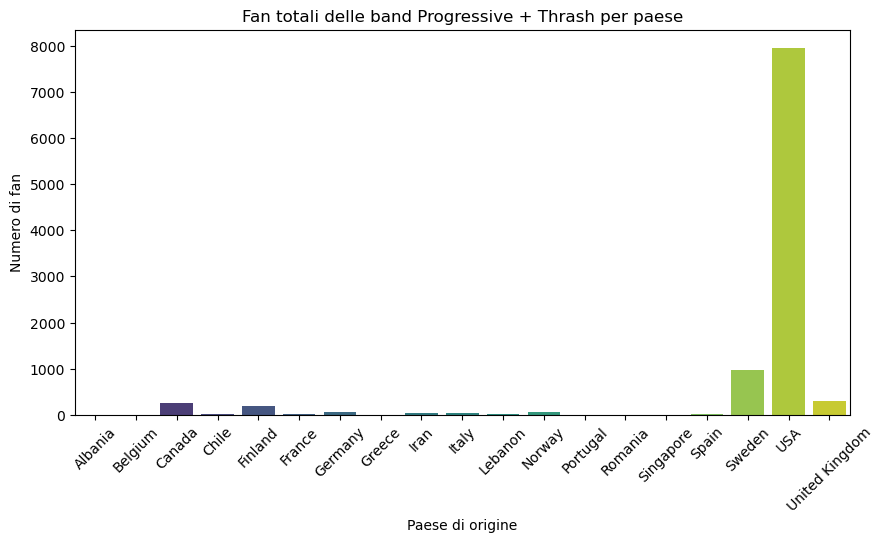

In [15]:
# Somma dei fan per paese di origine
fans_by_country = df_prog_thr.groupby('origin')['fans'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=fans_by_country, x='origin', y='fans', palette='viridis')

plt.title("Fan totali delle band Progressive + Thrash per paese")
plt.xlabel("Paese di origine")
plt.ylabel("Numero di fan")
plt.xticks(rotation=45)
plt.show()


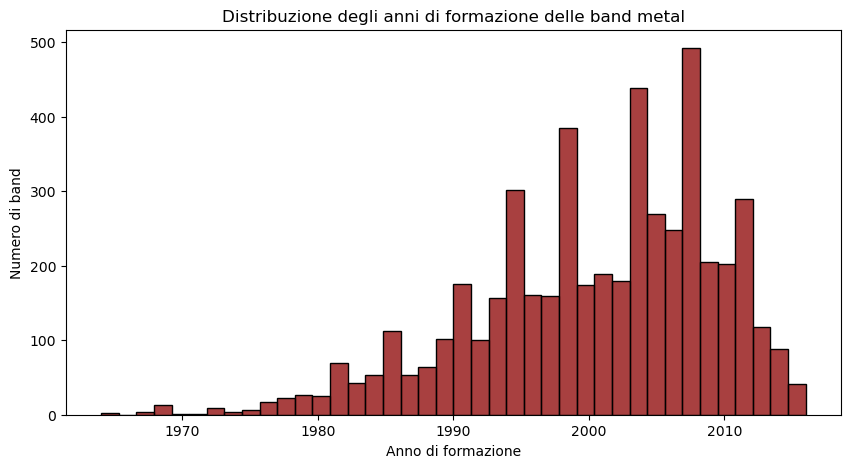

In [16]:
##Istogramma delle date di formazione delle band
##La colonna formed è numerica, ma può contenere valori strani (es. "-").Dobbiamo convertirla in numeri validi.

# Convertiamo la colonna 'formed' in numeri, ignorando errori
df['formed'] = pd.to_numeric(df['formed'], errors='coerce')

# Rimuoviamo eventuali NaN
df_formed = df.dropna(subset=['formed'])

plt.figure(figsize=(10,5))
sns.histplot(df_formed['formed'], bins=40, color='darkred')

plt.title("Distribuzione degli anni di formazione delle band metal")
plt.xlabel("Anno di formazione")
plt.ylabel("Numero di band")
plt.show()


C’è un forte aumento delle band formate dagli anni ’80 e ’90.
Questo riflette l’esplosione del metal in quel periodo (thrash, death, black, power).Dopo il 2000 la crescita continua ma più lentamente.Pochissime band sono nate prima degli anni ’70.

Esercizio Scarichiamo il dataset elections.csv dalla piattaforma o da https://github.com/plotly/datasets/blob/master/election.csv: • Con un grafico a barre confrontiamo i voti totali presi dai tre candidati (come somma di tutti i distretti) • Con un grafico a barre confrontiamo il numero di votanti per i primi dieci distretti

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carichiamo il dataset direttamente da GitHub
url = "https://raw.githubusercontent.com/plotly/datasets/master/election.csv"
df = pd.read_csv(url)

df.head()


,district,Coderre,Bergeron,Joly,total,winner,result,district_id
0,101-Bois-de-Liesse,2481,1829,3024,7334,Joly,plurality,101
1,102-Cap-Saint-Jacques,2525,1163,2675,6363,Joly,plurality,102
2,11-Sault-au-Récollet,3348,2770,2532,8650,Coderre,plurality,11
3,111-Mile-End,1734,4782,2514,9030,Bergeron,majority,111
4,112-DeLorimier,1770,5933,3044,10747,Bergeron,majority,112


In [18]:
df.columns


Index(['district', 'Coderre', 'Bergeron', 'Joly', 'total', 'winner', 'result',
       'district_id'],
      dtype='object')

C:\Users\Giordana\AppData\Local\Temp\ipykernel_18580\3867491995.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=totali_df, x='Candidato', y='Voti', palette='viridis')


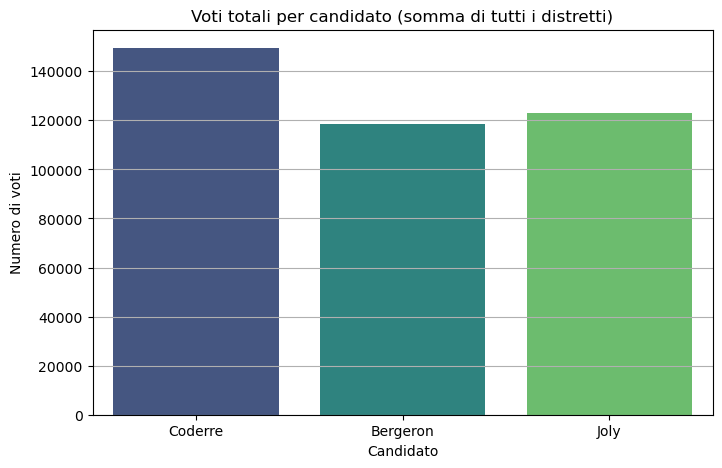

In [19]:
# Sommiamo i voti per ciascun candidato
totali = df[['Coderre', 'Bergeron', 'Joly']].sum()

# Convertiamo in DataFrame per Seaborn
totali_df = totali.reset_index()
totali_df.columns = ['Candidato', 'Voti']

plt.figure(figsize=(8,5))
sns.barplot(data=totali_df, x='Candidato', y='Voti', palette='viridis')

plt.title("Voti totali per candidato (somma di tutti i distretti)")
plt.ylabel("Numero di voti")
plt.grid(axis='y')
plt.show()


C:\Users\Giordana\AppData\Local\Temp\ipykernel_18580\1077894545.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df10, x='district', y='total', palette='magma')


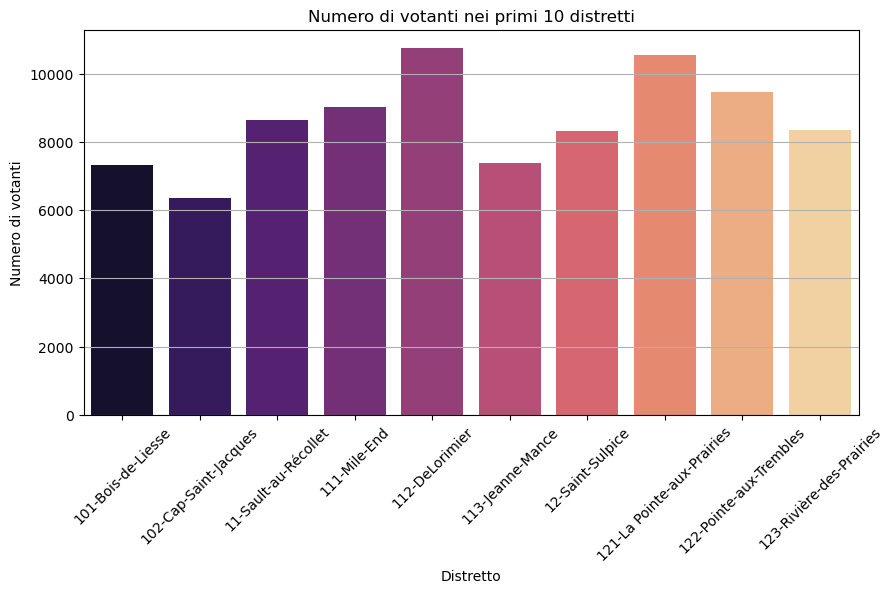

In [20]:
##Grafico a barre: numero di votanti nei primi 10 distretti
##La colonna che contiene il numero totale di votanti è:total --Quindi dobbiamo prendere i primi 10 distretti e confrontare i loro valori.

# Selezioniamo i primi 10 distretti
df10 = df.head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=df10, x='district', y='total', palette='magma')

plt.title("Numero di votanti nei primi 10 distretti")
plt.xlabel("Distretto")
plt.ylabel("Numero di votanti")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Cosa osserviamo?

✔ Voti totali per candidato : Il grafico mostra chiaramente chi ha ricevuto più voti complessivi. Le differenze tra i candidati sono molto evidenti.

✔ Votanti nei primi 10 distretti:I distretti hanno popolazioni molto diverse.Alcuni distretti hanno molti più votanti → influenzano maggiormente il totale.

Esercizio Scarichiamo i file party_in_nyc.csv dal dataset https://www.kaggle.com/datasets/somesnm/partynyc relativo a quante volte è stata chiamata la polizia per delle feste eccessivamente rumorose: • Realizziamo un grafico che mostra quante chiamate ci sono state per ogni città per tutti i tipi di locale • Qual è il rettangolo di latitudine e longitudine considerato dal dataset? • Quante segnalazioni sono state fatte per case private? • Con Seaborn visualizziamo il conteggio delle segnalazioni avvenute in ogni quartiere; che succede se aggiungiamo il parametro hue="Location Type"?

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("party_in_nyc.csv", encoding="latin1")

df.head()


,Created Date,Closed Date,Location Type,Incident Zip,City,Borough,Latitude,Longitude
0,2015-12-31 00:01:15,2015-12-31 03:48:04,Store/Commercial,10034.0,NEW YORK,MANHATTAN,40.866183,-73.918930
1,2015-12-31 00:02:48,2015-12-31 04:36:13,Store/Commercial,10040.0,NEW YORK,MANHATTAN,40.859324,-73.931237
2,2015-12-31 00:03:25,2015-12-31 00:40:15,Residential Building/House,10026.0,NEW YORK,MANHATTAN,40.799415,-73.953371
3,2015-12-31 00:03:26,2015-12-31 01:53:38,Residential Building/House,11231.0,BROOKLYN,BROOKLYN,40.678285,-73.994668
4,2015-12-31 00:05:10,2015-12-31 03:49:10,Residential Building/House,10033.0,NEW YORK,MANHATTAN,40.850304,-73.938516


In [22]:
df.columns


Index(['Created Date', 'Closed Date', 'Location Type', 'Incident Zip', 'City',
       'Borough', 'Latitude', 'Longitude'],
      dtype='object')

C:\Users\Giordana\AppData\Local\Temp\ipykernel_18580\3913065544.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="City", palette="viridis")


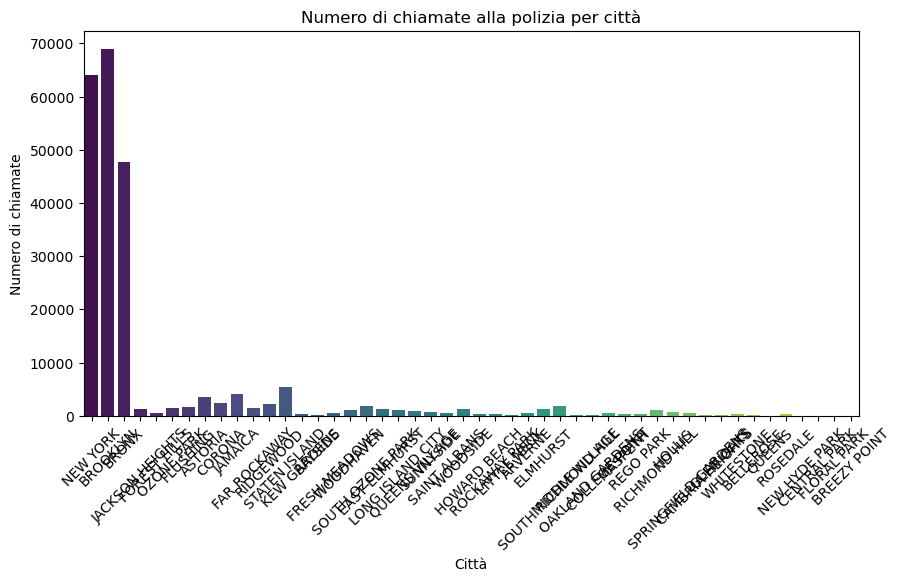

In [23]:
##Grafico: quante chiamate ci sono state per ogni città
##La colonna da usare è City.

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="City", palette="viridis")

plt.title("Numero di chiamate alla polizia per città")
plt.xlabel("Città")
plt.ylabel("Numero di chiamate")
plt.xticks(rotation=45)
plt.show()

Cosa mostra il grafico
Alcune città/borough hanno molte più chiamate (tipicamente Manhattan, Brooklyn).Le zone periferiche hanno meno segnalazioni.La distribuzione è molto sbilanciata.



In [24]:
##Qual è il rettangolo di latitudine e longitudine del dataset? Dobbiamo trovare min/max di Latitude e Longitude.

lat_min = df['Latitude'].min()
lat_max = df['Latitude'].max()
lon_min = df['Longitude'].min()
lon_max = df['Longitude'].max()

lat_min, lat_max, lon_min, lon_max

(40.498819681472185, 40.91217840308113, -74.25127710072611, -73.70230256557906)

Interpretazione
Il dataset copre un’area geografica delimitata da:

Latitudine: da lat_min a lat_max

Longitudine: da lon_min a lon_max

→ Questo è il bounding box dell’area di NYC considerata.

In [25]:
##Quante segnalazioni sono state fatte per case private?La colonna è Location Type.Cerchiamo valori che contengono “House”, “Residential”, “Private”.

mask_house = df['Location Type'].str.contains("House|Residential|Private", case=False, na=False)

num_house_calls = df[mask_house].shape[0]
num_house_calls

146642

C:\Users\Giordana\AppData\Local\Temp\ipykernel_18580\3777529679.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Borough", palette="magma")


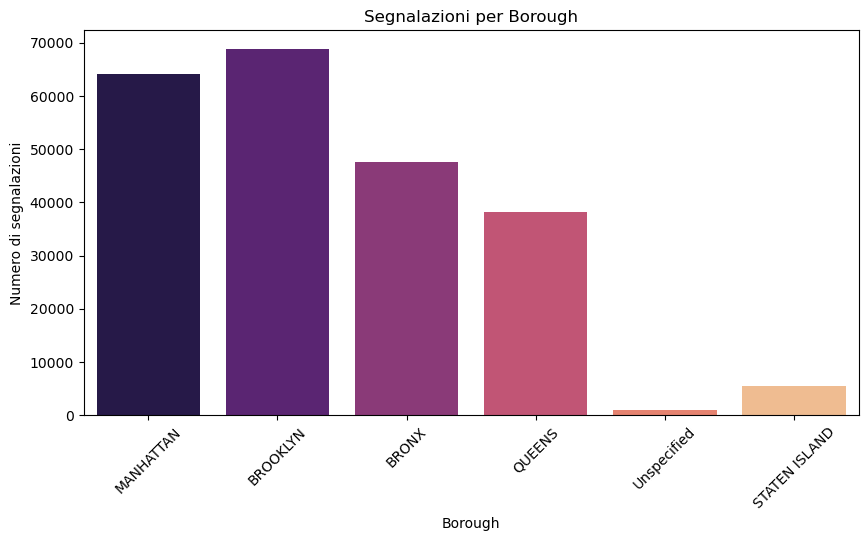

In [26]:
##Conteggio delle segnalazioni per quartiere (Borough)la colonna da usare è Borough.

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Borough", palette="magma")

plt.title("Segnalazioni per Borough")
plt.xlabel("Borough")
plt.ylabel("Numero di segnalazioni")
plt.xticks(rotation=45)
plt.show()

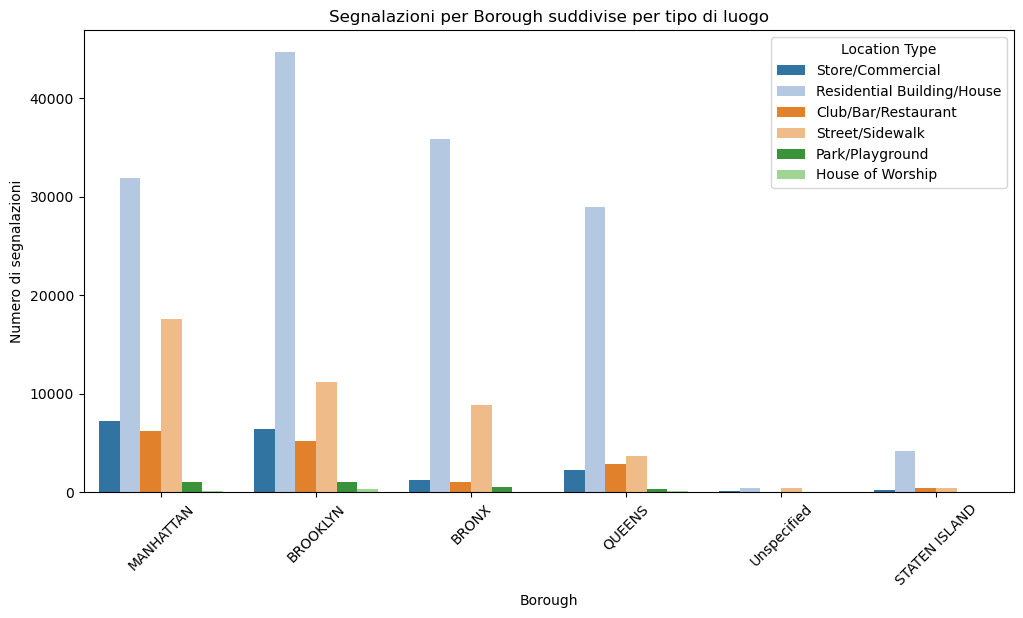

In [27]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Borough", hue="Location Type", palette="tab20")

plt.title("Segnalazioni per Borough suddivise per tipo di luogo")
plt.xlabel("Borough")
plt.ylabel("Numero di segnalazioni")
plt.xticks(rotation=45)
plt.show()


Interpretazione
Il grafico ora mostra per ogni borough la suddivisione delle chiamate per tipo di luogo.

Si vede chiaramente quali borough hanno più feste rumorose in case private, quali in bar, quali in club, ecc.

È molto più informativo perché mostra la composizione interna delle segnalazioni, non solo il totale.
